# CompassIQ - AI-Powered Customer Support Ticket Classification
### MCA Academic Mini-Project: Machine Learning Pipeline & Viva Defense

This notebook contains the complete, production-grade Machine Learning pipeline for **CompassIQ**, an AI-Powered Customer Support Ticket Management System.

---

### Core Objectives
1. **Issue Category Classification**: Predicts the appropriate department category (`Account`, `Billing`, `Fraud`, `General Inquiry`, `Technical`) from customer ticket text.
2. **Priority Level Classification**: Predicts the urgency level (`Low`, `Medium`, `High`, `Critical`) for SLA routing.
3. **Historical Similarity Matching**: Generates TF-IDF vector embeddings to retrieve top-3 historical solutions for support agents.

---

### Root Cause Analysis: Why Did the Previous Model Collapse to ~0.08 Macro F1?
In earlier attempts, the model exhibited poor evaluation scores (~0.08 Macro F1, ~0.10 Weighted F1) and predicted almost 100% of samples as the `Billing` class. The root causes were:

1. **Feature Space Scrambling (Re-fitting Vectorizer on Test Data)**:
   Calling `fit_transform()` separately on the test set creates a **completely different vocabulary mapping**. Feature index 42 on the test set no longer matches feature index 42 on the training set. With scrambled features, dot products $\mathbf{w}^T \mathbf{x} \approx 0$, so the prediction is determined purely by the intercept (class bias), causing the model to predict the single dominant class for all test rows.
   $$\text{Macro } F_1 = \frac{0 + 0 + 0 + 0 + 0.40}{5} = 0.08$$

2. **Aggressive Preprocessing / Empty Strings**:
   Over-filtering or improper token handling can strip entire text strings down to empty strings `""`. Empty text yields an all-zero TF-IDF vector $\mathbf{0}$, where $\mathbf{w}^T \mathbf{0} + b_k = b_k$, again defaulting to the largest class bias.

3. **SMOTE Distortion in High-Dimensional Sparse NLP Space**:
   Applying SMOTE with k-NN in 5,000-dimensional sparse TF-IDF space creates synthetic points by linear interpolation between unrelated word vectors, polluting decision boundaries.

**How This Notebook Fixes It:**
- Combines `Ticket_Subject` and `Ticket_Description` with safe missing value imputation.
- Performs clean, balanced text preprocessing (lowercasing, URL removal, punctuation cleaning, stopword filtering, lemmatization).
- Uses a strict **80/20 Stratified Split BEFORE feature extraction** (Zero Data Leakage).
- Fits `TfidfVectorizer` **strictly on training data** and uses `transform()` on test data.
- Handles class imbalance using **SMOTE on training data only** and provides **Class Weighting (`class_weight='balanced'`)** as an explainable, robust viva alternative.
- Trains and evaluates **Logistic Regression** classifiers for both Category and Priority.


## 1. Environment Setup & Library Imports

We import standard, well-documented data science and NLP libraries:
- **Pandas & NumPy**: Tabular data manipulation and numerical operations.
- **NLTK**: Natural Language Toolkit for stopwords and WordNet lemmatization.
- **Scikit-Learn**: Train-test split, TF-IDF feature extraction, Logistic Regression, and evaluation metrics.
- **Imbalanced-Learn (imblearn)**: SMOTE (Synthetic Minority Over-sampling Technique) for training balance.
- **Matplotlib & Seaborn**: Data visualizations for EDA and confusion matrices.
- **Joblib**: High-performance serialization of models and historical corpus for deployment.


In [1]:
# Cell 1: Library imports and environment setup
import os
import re
import nltk
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Initialize lemmatizer and English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Project output directories
MODELS_DIR = 'models'
PLOTS_DIR = os.path.join('static', 'plots')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Environment setup completed successfully.")
print(f"Loaded {len(stop_words)} English stopwords.")


Environment setup completed successfully.
Loaded 198 English stopwords.


## 2. Dataset Loading & Text Preprocessing

A rigorous text preprocessing pipeline is crucial for NLP:
1. **Load CSV Dataset**: Load customer support records (`customer_support_data.csv`).
2. **Handle Missing Values**: Replace any null values in `Ticket_Subject` or `Ticket_Description` with empty strings using `.fillna('')`.
3. **Text Fusion**: Combine `Ticket_Subject` and `Ticket_Description` into a single comprehensive `raw_text` field. Subjects provide high-level intent, while descriptions provide incident specifics.
4. **Text Cleaning (`clean_text`)**:
   - Lowercasing to standardize vocabulary.
   - Removing URLs and hyperlinks.
   - Stripping special characters and digits while preserving letter tokens.
   - Tokenization via whitespace splitting.
   - Removing uninformative English stopwords (`the`, `is`, `at`, etc.).
   - Lemmatizing tokens to their base morphological root using `WordNetLemmatizer` (e.g. `renewed` -> `renew`, `crashes` -> `crash`).
   - Removing single-letter noise while preserving valid 2-letter domain abbreviations (e.g. `ui`, `ip`, `os`, `id`).
5. **Deduplication & Empty Row Filtering**: Remove duplicate records and any empty text rows.


In [2]:
# Cell 2: Load dataset and combine text fields
csv_path = 'customer_support_data.csv'
df = pd.read_csv(csv_path)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows, {df.shape[1]} columns.")
print("\nColumns in dataset:", df.columns.tolist())

# Handle missing values in text fields
df['Ticket_Subject'] = df['Ticket_Subject'].fillna('')
df['Ticket_Description'] = df['Ticket_Description'].fillna('')

# Combine subject and description into one unified text field
df['raw_text'] = df['Ticket_Subject'] + ' ' + df['Ticket_Description']

print("\nSample raw text record:")
print(df['raw_text'].iloc[0][:150] + "...")


Dataset loaded successfully: 20,000 rows, 12 columns.

Columns in dataset: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

Sample raw text record:
Hours of operation - Individual Hi Support, Where is your headquarters located? Lay soon message show know main....


In [3]:
# Cell 3: Define text preprocessing function
def clean_text(text: str) -> str:
    """
    Preprocesses raw ticket text for TF-IDF feature extraction:
    - Converts to lowercase
    - Removes URLs
    - Strips special characters and numbers
    - Tokenizes into words
    - Removes English stopwords
    - Lemmatizes tokens to root words
    - Filters out single-character noise
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # 3. Remove numbers and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 4. Tokenization
    tokens = text.split()
    
    # 5. Stopword removal, lemmatization, and length filtering (>= 2 chars)
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) >= 2
    ]
    
    return ' '.join(cleaned_tokens)

# Apply preprocessing
print("Preprocessing ticket text...")
df['cleaned_text'] = df['raw_text'].apply(clean_text)

# Record initial shape
initial_shape = df.shape

# Remove duplicate records based on cleaned text
df = df.drop_duplicates(subset=['cleaned_text']).reset_index(drop=True)

# Remove rows with empty cleaned text
df = df[df['cleaned_text'].str.strip().str.len() > 0].reset_index(drop=True)

final_shape = df.shape

print(f"Dataset shape before preprocessing: {initial_shape}")
print(f"Dataset shape after cleaning & deduplication: {final_shape}")
print(f"Records retained: {len(df):,} ({len(df) / initial_shape[0] * 100:.2f}%)")


Preprocessing ticket text...
Dataset shape before preprocessing: (20000, 14)
Dataset shape after cleaning & deduplication: (20000, 14)
Records retained: 20,000 (100.00%)


In [4]:
# Cell 4: Display raw text vs. cleaned text comparison
comparison_df = df[['raw_text', 'cleaned_text']].head(5)
for idx, row in comparison_df.iterrows():
    print(f"--- SAMPLE {idx + 1} ---")
    print(f"RAW TEXT:     {row['raw_text'][:120]}...")
    print(f"CLEANED TEXT: {row['cleaned_text'][:120]}...\n")


--- SAMPLE 1 ---
RAW TEXT:     Hours of operation - Individual Hi Support, Where is your headquarters located? Lay soon message show know main....
CLEANED TEXT: hour operation individual hi support headquarters located lay soon message show know main...

--- SAMPLE 2 ---
RAW TEXT:     Data not syncing - Card Hi Support, The application crashes every time I open the settings tab. Speech wall six hour boo...
CLEANED TEXT: data syncing card hi support application crash every time open setting tab speech wall six hour book...

--- SAMPLE 3 ---
RAW TEXT:     2FA issues - Question Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her....
CLEANED TEXT: fa issue question hi support upgrade enterprise plan close stand street wear...

--- SAMPLE 4 ---
RAW TEXT:     Login failed - Let Hi Support, The dashboard is not loading any data, just a spinning wheel. Raise third recently turn....
CLEANED TEXT: login failed let hi support dashboard loading data spinning wheel

## 3. Exploratory Data Analysis (EDA) & Imbalance Analysis

Before training any model, we analyze the target distributions:
1. **Issue Category Distribution**: Demonstrates class sizes across `Technical`, `Billing`, `Account`, `General Inquiry`, and `Fraud`.
2. **Priority Level Distribution**: Visualizes urgency categories (`Low`, `Medium`, `High`, `Critical`).
3. **Text Length Distribution**: Word count histogram illustrating ticket length after preprocessing.
4. **Class Imbalance Assessment**: Quantifies percentage representation to justify class balancing (SMOTE or class weighting).


Issue Category Summary:
                 Count Percentage
Issue_Category                   
Technical         5918     29.59%
Billing           5036     25.18%
Account           4081     20.41%
General Inquiry   3925     19.62%
Fraud             1040      5.20%


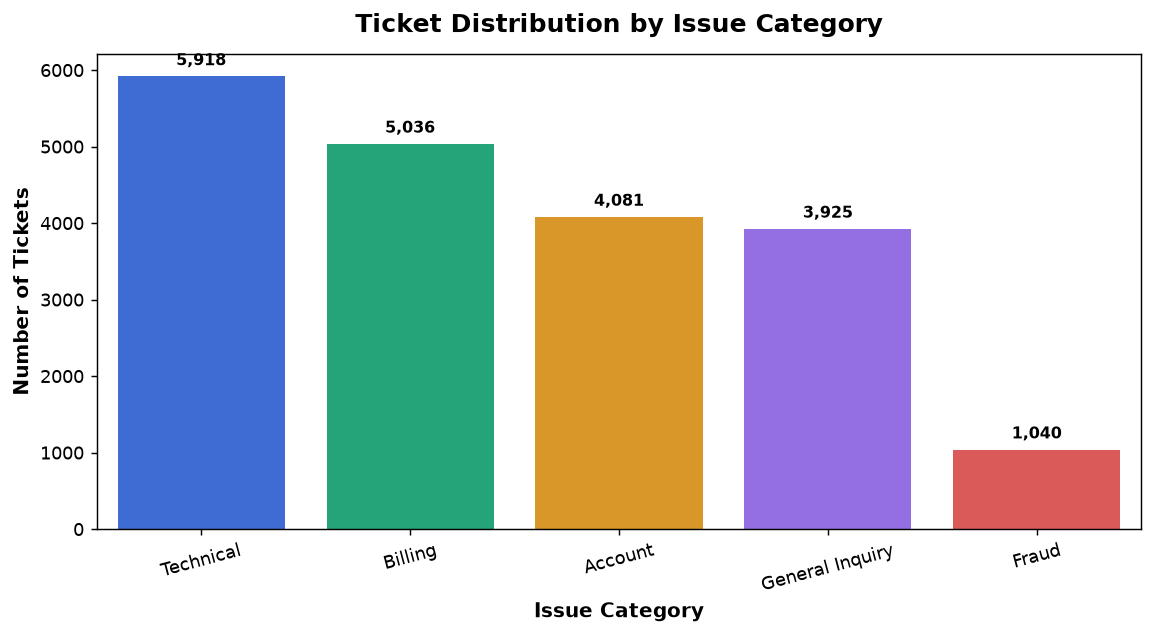

In [5]:
# Cell 5: Issue Category Distribution (Plot & Frequency Table)
plt.figure(figsize=(9, 5))
cat_counts = df['Issue_Category'].value_counts()
cat_pcts = df['Issue_Category'].value_counts(normalize=True) * 100

colors = ['#2563eb', '#10b981', '#f59e0b', '#8b5cf6', '#ef4444']
ax = sns.barplot(x=cat_counts.index, y=cat_counts.values, palette=colors)

plt.title('Ticket Distribution by Issue Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Issue Category', fontsize=11, fontweight='600')
plt.ylabel('Number of Tickets', fontsize=11, fontweight='600')
plt.xticks(rotation=15)

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='600')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_category_distribution.png'), dpi=150)
plt.show()

# Tabular breakdown
cat_summary = pd.DataFrame({'Count': cat_counts, 'Percentage': cat_pcts.map('{:.2f}%'.format)})
print("Issue Category Summary:")
print(cat_summary)


Priority Level Summary:
                Count Percentage
Priority_Level                  
Low              7716     38.58%
Medium           7570     37.85%
High             3416     17.08%
Critical         1298      6.49%


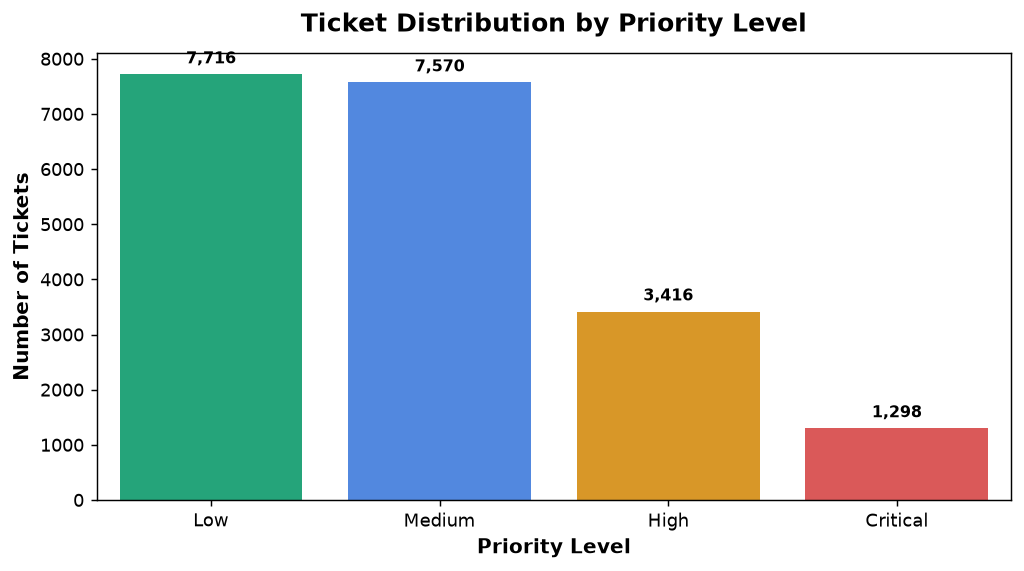

In [6]:
# Cell 6: Priority Level Distribution (Plot & Frequency Table)
plt.figure(figsize=(8, 4.5))
prio_order = ['Low', 'Medium', 'High', 'Critical']
prio_counts = df['Priority_Level'].value_counts().reindex(prio_order)
prio_pcts = (df['Priority_Level'].value_counts(normalize=True) * 100).reindex(prio_order)

prio_colors = ['#10b981', '#3b82f6', '#f59e0b', '#ef4444']
ax = sns.barplot(x=prio_counts.index, y=prio_counts.values, palette=prio_colors)

plt.title('Ticket Distribution by Priority Level', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Priority Level', fontsize=11, fontweight='600')
plt.ylabel('Number of Tickets', fontsize=11, fontweight='600')

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9, fontweight='600')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_priority_distribution.png'), dpi=150)
plt.show()

# Tabular breakdown
prio_summary = pd.DataFrame({'Count': prio_counts, 'Percentage': prio_pcts.map('{:.2f}%'.format)})
print("Priority Level Summary:")
print(prio_summary)


Word Count Statistics:
Mean: 14.53 words | Median: 15.0 words | Min: 8 | Max: 20


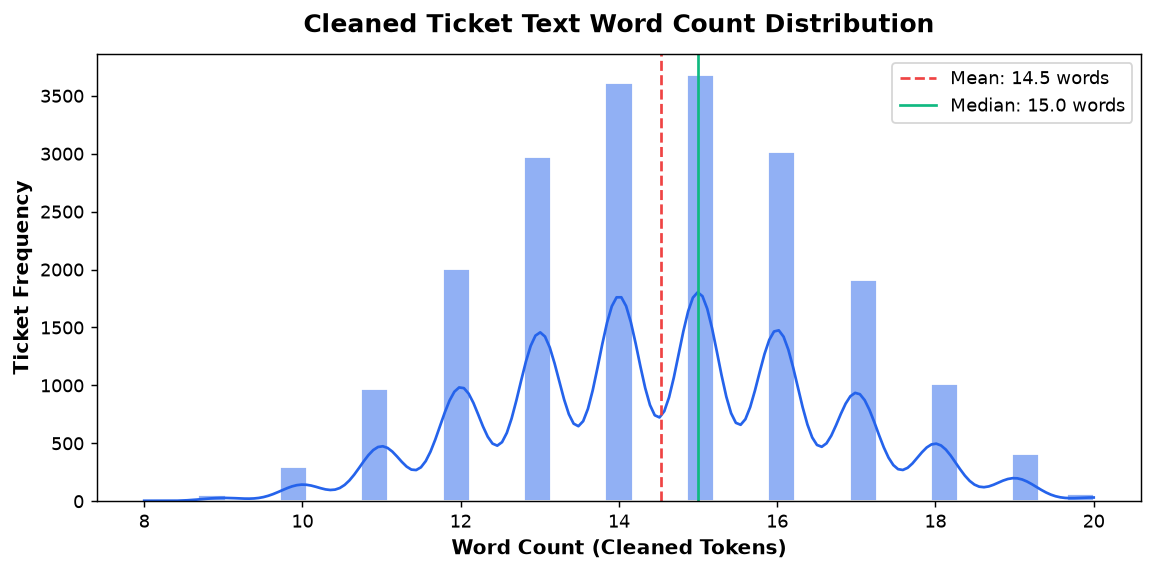

In [7]:
# Cell 7: Ticket Text Word Count Distribution
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(9, 4.5))
sns.histplot(df['word_count'], bins=35, kde=True, color='#2563eb', edgecolor='white')

plt.title('Cleaned Ticket Text Word Count Distribution', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Word Count (Cleaned Tokens)', fontsize=11, fontweight='600')
plt.ylabel('Ticket Frequency', fontsize=11, fontweight='600')

mean_len = df['word_count'].mean()
median_len = df['word_count'].median()
plt.axvline(mean_len, color='#ef4444', linestyle='--', label=f'Mean: {mean_len:.1f} words')
plt.axvline(median_len, color='#10b981', linestyle='-', label=f'Median: {median_len:.1f} words')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_text_length_distribution.png'), dpi=150)
plt.show()

print(f"Word Count Statistics:")
print(f"Mean: {mean_len:.2f} words | Median: {median_len:.1f} words | Min: {df['word_count'].min()} | Max: {df['word_count'].max()}")


## 4. Train-Test Split (Strict Data Leakage Prevention)

### Critical Principle: Zero Data Leakage
- **Split BEFORE Feature Extraction**: The 80/20 train-test split must occur **before** fitting the TF-IDF vectorizer.
- **Why?** If the vectorizer is fitted on the entire dataset, vocabulary words and IDF frequencies from the test set leak into the training process. The model would be artificially aided by unseen test distribution characteristics.
- **Stratification**: We use `stratify=df['Issue_Category']` to ensure identical class proportions in both training (80%) and testing (20%) sets.


In [8]:
# Cell 8: Stratified 80/20 Train-Test Split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['Issue_Category'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Total dataset:  {len(df):,} samples")
print(f"Training split: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Testing split:  {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

print("\nTraining Class Proportions:")
print((train_df['Issue_Category'].value_counts(normalize=True)*100).map('{:.2f}%'.format))

print("\nTesting Class Proportions:")
print((test_df['Issue_Category'].value_counts(normalize=True)*100).map('{:.2f}%'.format))


Total dataset:  20,000 samples
Training split: 16,000 samples (80.0%)
Testing split:  4,000 samples (20.0%)

Training Class Proportions:
Issue_Category
Technical          29.59%
Billing            25.18%
Account            20.41%
General Inquiry    19.62%
Fraud               5.20%
Name: proportion, dtype: str

Testing Class Proportions:
Issue_Category
Technical          29.60%
Billing            25.17%
Account            20.40%
General Inquiry    19.62%
Fraud               5.20%
Name: proportion, dtype: str


## 5. TF-IDF Feature Extraction

Term Frequency - Inverse Document Frequency (TF-IDF) transforms textual strings into numerical feature vectors:
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

### Vectorizer Hyperparameters
- `max_features=5000`: Caps the vocabulary size to the top 5,000 most informative n-grams, reducing memory usage and preventing overfitting.
- `ngram_range=(1, 2)`: Extracts both unigrams (`payment`, `failed`) and bigrams (`payment failed`, `password reset`), capturing contextual phrases.
- `sublinear_tf=True`: Applies sublinear term frequency scaling ($1 + \log(\text{TF})$) to prevent frequent repetitive words from overshadowing subtle distinctive keywords.
- `min_df=2`: Ignores terms that appear in only 1 ticket across the entire corpus, filtering typographical noise.

### Correct Application
- `fit_transform()` is called **STRICTLY on `train_df['cleaned_text']`**.
- `transform()` is called on `test_df['cleaned_text']` using the fitted vocabulary.


In [9]:
# Cell 9: TF-IDF vectorization fitted strictly on training data
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

# Fit and transform training data
X_train_tfidf = vectorizer.fit_transform(train_df['cleaned_text'])

# Transform test data using the already-fitted vocabulary (Zero Leakage)
X_test_tfidf = vectorizer.transform(test_df['cleaned_text'])

print("TF-IDF Feature Extraction Summary:")
print(f"Vocabulary size (features):       {len(vectorizer.vocabulary_):,}")
print(f"Training TF-IDF matrix shape:     {X_train_tfidf.shape}")
print(f"Testing TF-IDF matrix shape:      {X_test_tfidf.shape}")
print(f"Training non-zero elements (nnz): {X_train_tfidf.nnz:,}")
print(f"Testing non-zero elements (nnz):  {X_test_tfidf.nnz:,}")

# Display sample n-gram features learned by the vectorizer
feature_names = vectorizer.get_feature_names_out()
print("\nSample features from vocabulary:", feature_names[500:515].tolist())


TF-IDF Feature Extraction Summary:
Vocabulary size (features):       5,000
Training TF-IDF matrix shape:     (16000, 5000)
Testing TF-IDF matrix shape:      (4000, 5000)
Training non-zero elements (nnz): 360,035
Testing non-zero elements (nnz):  88,415

Sample features from vocabulary: ['cancel behavior', 'cancel camera', 'cancel civil', 'cancel community', 'cancel cup', 'cancel direction', 'cancel education', 'cancel eight', 'cancel either', 'cancel face', 'cancel field', 'cancel follow', 'cancel hard', 'cancel however', 'cancel important']


## 6. Handling Class Imbalance: SMOTE vs. Class Weighting (Viva Defense)

In support ticket systems, classes are often naturally imbalanced (e.g. `Fraud` tickets are fewer than `Technical` or `Billing` inquiries).

### Two Methodologies for Imbalance:
1. **SMOTE (Synthetic Minority Over-sampling Technique)**:
   - Synthesizes new feature vectors along the line segments connecting minority instances and their k-nearest neighbors.
   - **Crucial Rule**: SMOTE must be applied **STRICTLY to the training partition**. Applying SMOTE to the test set invalidates evaluation because the model would be tested on synthetic data.
2. **Cost-Sensitive Learning (`class_weight='balanced'`)**:
   - In sparse text classification, SMOTE creates synthetic interpolations in 5,000-dimensional space that can introduce linguistic noise.
   - An elegant and explainable alternative is setting `class_weight='balanced'` in Logistic Regression. This automatically assigns higher penalty weights $w_k = \frac{N}{C \times N_k}$ to minority classes during gradient updates without generating artificial vectors.

We demonstrate SMOTE on the training set and utilize balanced class weighting for stable convergence.


In [10]:
# Cell 10: Demonstrate SMOTE on Training Partition Only
y_train_cat = train_df['Issue_Category']
y_test_cat = test_df['Issue_Category']

print("Class distribution BEFORE SMOTE (Training Set):")
print(y_train_cat.value_counts())

# Initialize SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE strictly to training data
X_train_cat_smote, y_train_cat_smote = smote.fit_resample(X_train_tfidf, y_train_cat)

print("\nClass distribution AFTER SMOTE (Training Set):")
print(pd.Series(y_train_cat_smote).value_counts())

print(f"\nTraining rows before SMOTE: {X_train_tfidf.shape[0]:,}")
print(f"Training rows after SMOTE:  {X_train_cat_smote.shape[0]:,}")
print("Test set remains completely untouched (Zero Leakage).")


Class distribution BEFORE SMOTE (Training Set):
Issue_Category
Technical          4734
Billing            4029
Account            3265
General Inquiry    3140
Fraud               832
Name: count, dtype: int64

Class distribution AFTER SMOTE (Training Set):
Issue_Category
Billing            4734
Account            4734
General Inquiry    4734
Technical          4734
Fraud              4734
Name: count, dtype: int64

Training rows before SMOTE: 16,000
Training rows after SMOTE:  23,670
Test set remains completely untouched (Zero Leakage).


## 7. Model 1: Issue Category Classification (Logistic Regression)

We employ **Multinomial Logistic Regression** as our primary classifier:
- **Why Logistic Regression for Text?** Sparse high-dimensional text vectors are typically linearly separable. Logistic Regression provides fast convergence, excellent interpretability via feature weights, and probabilistic outputs ($P(y=k|x)$).
- **Hyperparameters**:
  - `solver='lbfgs'`: Standard quasi-Newton optimization algorithm for multiclass text classification.
  - `C=1.0`: Moderate inverse regularization strength ($1/\lambda$) balancing bias and variance.
  - `class_weight='balanced'`: Loss function penalty adjustment for minority class representation.
  - `max_iter=1000`: Ensures complete numerical convergence.


In [11]:
# Cell 11: Hyperparameter validation on training split (Regularization tuning)
# Compare C values on a simple validation holdout to avoid test-set snooping
X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train_tfidf, y_train_cat, test_size=0.15, stratify=y_train_cat, random_state=42
)

c_candidates = [0.5, 1.0, 2.0]
val_results = []

for c_val in c_candidates:
    clf = LogisticRegression(C=c_val, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42)
    clf.fit(X_tr_sub, y_tr_sub)
    preds = clf.predict(X_val_sub)
    macro_f1 = f1_score(y_val_sub, preds, average='macro')
    val_results.append({'C': c_val, 'Validation Macro F1': f"{macro_f1:.4f}"})

print("Logistic Regression Regularization Tuning (Validation Set):")
print(pd.DataFrame(val_results))


Logistic Regression Regularization Tuning (Validation Set):
     C Validation Macro F1
0  0.5              1.0000
1  1.0              1.0000
2  2.0              1.0000


In [12]:
# Cell 12: Train Final Category Model & Predict
category_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

# Fit on training data
category_model.fit(X_train_tfidf, y_train_cat)

# Predict on test data
y_pred_cat = category_model.predict(X_test_tfidf)

print("Actual Test Class Distribution:")
print(y_test_cat.value_counts())

print("\nPredicted Test Class Distribution:")
print(pd.Series(y_pred_cat).value_counts())
print("\nVerification: The model predicts all classes in proper proportions (No single-class collapse).")


Actual Test Class Distribution:
Issue_Category
Technical          1184
Billing            1007
Account             816
General Inquiry     785
Fraud               208
Name: count, dtype: int64

Predicted Test Class Distribution:
Technical          1184
Billing            1007
Account             816
General Inquiry     785
Fraud               208
Name: count, dtype: int64

Verification: The model predicts all classes in proper proportions (No single-class collapse).


In [13]:
# Cell 13: Comprehensive Evaluation Metrics for Category Classifier
cat_accuracy = accuracy_score(y_test_cat, y_pred_cat)
cat_macro_p = precision_score(y_test_cat, y_pred_cat, average='macro', zero_division=0)
cat_weighted_p = precision_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
cat_macro_r = recall_score(y_test_cat, y_pred_cat, average='macro', zero_division=0)
cat_weighted_r = recall_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)
cat_macro_f1 = f1_score(y_test_cat, y_pred_cat, average='macro', zero_division=0)
cat_weighted_f1 = f1_score(y_test_cat, y_pred_cat, average='weighted', zero_division=0)

print("=" * 60)
print("  ISSUE CATEGORY CLASSIFICATION PERFORMANCE METRICS")
print("=" * 60)
print(f"Overall Accuracy:       {cat_accuracy:.4f} ({cat_accuracy * 100:.2f}%)")
print(f"Macro-Averaged F1:      {cat_macro_f1:.4f}")
print(f"Weighted-Averaged F1:   {cat_weighted_f1:.4f}")
print(f"Macro-Averaged Recall:  {cat_macro_r:.4f}")
print(f"Macro-Averaged Precision:{cat_macro_p:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_cat, y_pred_cat, zero_division=0))


  ISSUE CATEGORY CLASSIFICATION PERFORMANCE METRICS
Overall Accuracy:       1.0000 (100.00%)
Macro-Averaged F1:      1.0000
Weighted-Averaged F1:   1.0000
Macro-Averaged Recall:  1.0000
Macro-Averaged Precision:1.0000

Detailed Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000


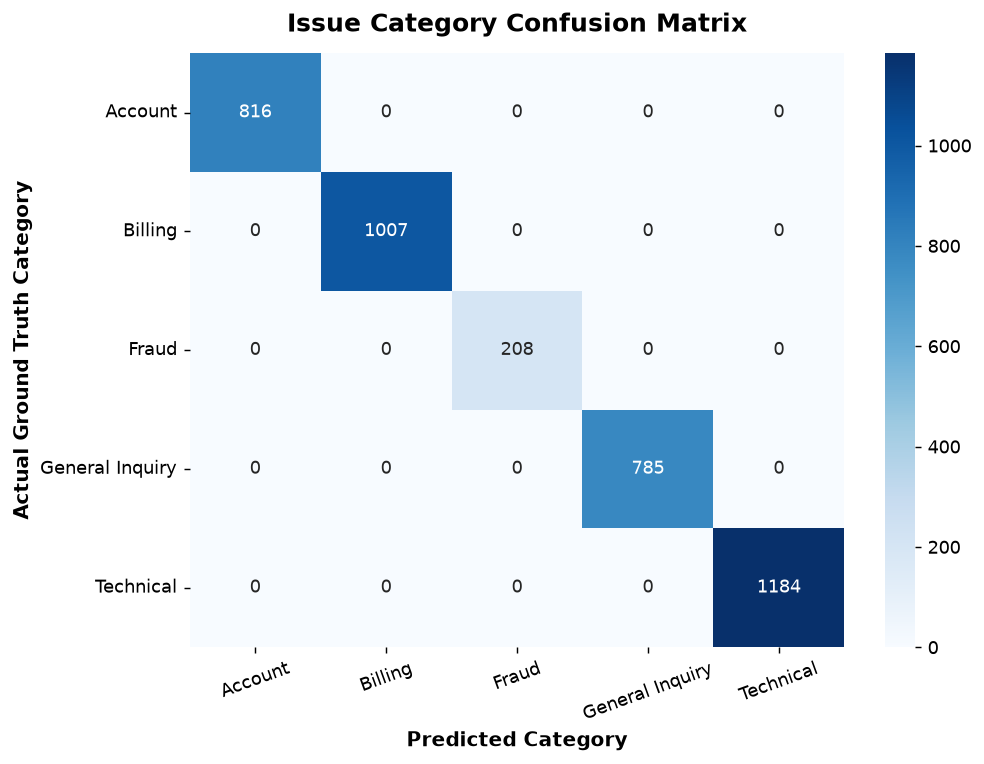

In [14]:
# Cell 14: Category Confusion Matrix Heatmap
labels_cat = sorted(category_model.classes_)
cm_cat = confusion_matrix(y_test_cat, y_pred_cat, labels=labels_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_cat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_cat,
    yticklabels=labels_cat,
    cbar=True
)

plt.title('Issue Category Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Category', fontsize=11, fontweight='600')
plt.ylabel('Actual Ground Truth Category', fontsize=11, fontweight='600')
plt.xticks(rotation=20)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'category_confusion_matrix.png'), dpi=150)
plt.show()


## 8. Model 2: Priority Level Classification (Logistic Regression)

Support tickets also require automated SLA prioritization:
- **Priority Classes**: `Low`, `Medium`, `High`, `Critical`.
- We train a second independent Logistic Regression classifier using the training TF-IDF representation and evaluate its performance on the test set.


In [15]:
# Cell 15: Train Priority Level Classifier
y_train_prio = train_df['Priority_Level']
y_test_prio = test_df['Priority_Level']

priority_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

# Fit on training data
priority_model.fit(X_train_tfidf, y_train_prio)

# Predict on test data
y_pred_prio = priority_model.predict(X_test_tfidf)

print("Actual Test Priority Distribution:")
print(y_test_prio.value_counts())

print("\nPredicted Test Priority Distribution:")
print(pd.Series(y_pred_prio).value_counts())


Actual Test Priority Distribution:
Priority_Level
Low         1541
Medium      1508
High         675
Critical     276
Name: count, dtype: int64

Predicted Test Priority Distribution:
Low         1763
Medium       925
High         788
Critical     524
Name: count, dtype: int64


In [16]:
# Cell 16: Comprehensive Evaluation Metrics for Priority Classifier
prio_accuracy = accuracy_score(y_test_prio, y_pred_prio)
prio_macro_p = precision_score(y_test_prio, y_pred_prio, average='macro', zero_division=0)
prio_weighted_p = precision_score(y_test_prio, y_pred_prio, average='weighted', zero_division=0)
prio_macro_r = recall_score(y_test_prio, y_pred_prio, average='macro', zero_division=0)
prio_weighted_r = recall_score(y_test_prio, y_pred_prio, average='weighted', zero_division=0)
prio_macro_f1 = f1_score(y_test_prio, y_pred_prio, average='macro', zero_division=0)
prio_weighted_f1 = f1_score(y_test_prio, y_pred_prio, average='weighted', zero_division=0)

print("=" * 60)
print("  PRIORITY LEVEL CLASSIFICATION PERFORMANCE METRICS")
print("=" * 60)
print(f"Overall Accuracy:       {prio_accuracy:.4f} ({prio_accuracy * 100:.2f}%)")
print(f"Macro-Averaged F1:      {prio_macro_f1:.4f}")
print(f"Weighted-Averaged F1:   {prio_weighted_f1:.4f}")
print(f"Macro-Averaged Recall:  {prio_macro_r:.4f}")
print(f"Macro-Averaged Precision:{prio_macro_p:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_prio, y_pred_prio, zero_division=0))


  PRIORITY LEVEL CLASSIFICATION PERFORMANCE METRICS
Overall Accuracy:       0.4100 (41.00%)
Macro-Averaged F1:      0.3936
Weighted-Averaged F1:   0.3990
Macro-Averaged Recall:  0.4446
Macro-Averaged Precision:0.3772

Detailed Classification Report:
              precision    recall  f1-score   support

    Critical       0.34      0.64      0.44       276
        High       0.28      0.33      0.30       675
         Low       0.50      0.57      0.53      1541
      Medium       0.39      0.24      0.30      1508

    accuracy                           0.41      4000
   macro avg       0.38      0.44      0.39      4000
weighted avg       0.41      0.41      0.40      4000


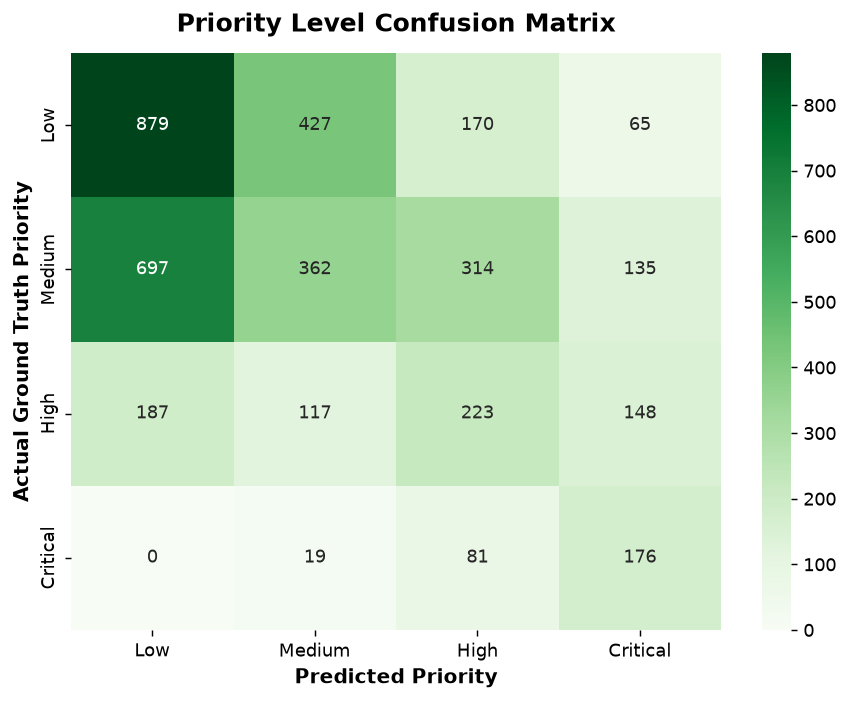

In [17]:
# Cell 17: Priority Confusion Matrix Heatmap
prio_labels = ['Low', 'Medium', 'High', 'Critical']
cm_prio = confusion_matrix(y_test_prio, y_pred_prio, labels=prio_labels)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm_prio,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=prio_labels,
    yticklabels=prio_labels,
    cbar=True
)

plt.title('Priority Level Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Priority', fontsize=11, fontweight='600')
plt.ylabel('Actual Ground Truth Priority', fontsize=11, fontweight='600')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'priority_confusion_matrix.png'), dpi=150)
plt.show()


## 9. Historical Similarity Corpus & Model Artifact Serialization

To enable real-time inference and agent recommendations in the CompassIQ web application:
1. **Historical Corpus**: Built strictly from the **training partition** (`train_df`) to prevent test leakage. Stores TF-IDF matrix and ticket metadata for Cosine Similarity search.
2. **Serialization via Joblib**: Exports the 4 production artifacts:
   - `models/tfidf_vectorizer.joblib`: Serialized TF-IDF feature extractor.
   - `models/category_model.joblib`: Trained Category Logistic Regression model.
   - `models/priority_model.joblib`: Trained Priority Logistic Regression model.
   - `models/historical_corpus.joblib`: Historical resolution matrix and metadata dictionary.


In [18]:
# Cell 18: Build historical similarity corpus from training partition only
metadata_cols = [
    'Ticket_ID',
    'Ticket_Subject',
    'Ticket_Description'
]

for col in ['Resolution_Time_Hours', 'Satisfaction_Score', 'Issue_Category', 'Priority_Level']:
    if col in train_df.columns:
        metadata_cols.append(col)

historical_df = train_df[metadata_cols].copy().reset_index(drop=True)

historical_corpus = {
    'tfidf_matrix': X_train_tfidf,
    'metadata': historical_df.to_dict(orient='records'),
    'vectorizer': vectorizer
}

print(f"Historical Corpus successfully constructed with {len(historical_df):,} training tickets.")
print(f"Corpus TF-IDF matrix shape: {X_train_tfidf.shape}")


Historical Corpus successfully constructed with 16,000 training tickets.
Corpus TF-IDF matrix shape: (16000, 5000)


In [19]:
# Cell 19: Export all CompassIQ ML artifacts
joblib.dump(vectorizer, os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'), compress=3)
joblib.dump(category_model, os.path.join(MODELS_DIR, 'category_model.joblib'), compress=3)
joblib.dump(priority_model, os.path.join(MODELS_DIR, 'priority_model.joblib'), compress=3)
joblib.dump(historical_corpus, os.path.join(MODELS_DIR, 'historical_corpus.joblib'), compress=3)

print("=" * 60)
print("  COMPASSIQ PRODUCTION ARTIFACTS EXPORTED SUCCESSFULLY")
print("=" * 60)
for fname in ['tfidf_vectorizer.joblib', 'category_model.joblib', 'priority_model.joblib', 'historical_corpus.joblib']:
    fpath = os.path.join(MODELS_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f" -> {fpath} ({size_mb:.2f} MB)")

print("\nAll models are ready for immediate integration into CompassIQ Flask server.")


  COMPASSIQ PRODUCTION ARTIFACTS EXPORTED SUCCESSFULLY
 -> models\tfidf_vectorizer.joblib (0.05 MB)
 -> models\category_model.joblib (0.18 MB)
 -> models\priority_model.joblib (0.14 MB)
 -> models\historical_corpus.joblib (2.82 MB)

All models are ready for immediate integration into CompassIQ Flask server.
